--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head() # mostrar las primeras 5 filas de users

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [5]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (500, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos:") # Cantidad de valores nulos
print(users.isna().sum())
print("\nProporción de valores nulos:") # Proporción de valores nulos
print(users.isna().mean().round(4))

Cantidad de valores nulos:
user_id         0
age             0
churn_date    462
city            0
first_name      0
last_name       0
reg_date        0
tariff          0
dtype: int64

Proporción de valores nulos:
user_id       0.000
age           0.000
churn_date    0.924
city          0.000
first_name    0.000
last_name     0.000
reg_date      0.000
tariff        0.000
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())
print("\nProporción de valores nulos:")
print(usage.isna().mean().round(4))

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.0000
user_id     0.0000
type        0.0000
date        0.0012
duration    0.5519
length      0.4474
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?
- ## Diagnóstico de valores nulos

**users:**
- `churn_date`: 462 nulos (92.4%) — normal, representa clientes activos que no se han dado de baja. Se conserva como NaN.
- Resto de columnas: sin nulos. 

**usage:**
- `date`: 50 nulos (0.12%) — porcentaje muy bajo, se eliminarán esas filas.
- `duration`: 22,076 nulos (55.19%) — esperado, solo las llamadas tienen duración. No es un error.
- `length`: 17,896 nulos (44.74%) — esperado, solo los mensajes tienen longitud. No es un error.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,500.000000,500.00000
mean,1249.500000,46.58800
std,144.481833,16.66763
min,1000.000000,18.00000
25%,1124.750000,32.00000
50%,1249.500000,46.00000
75%,1374.250000,62.00000
max,1499.000000,75.00000


- La columna `user_id`: 500 valores, rango 1000-1499, sin valores imposibles. 
- La columna `age`: 500 valores, rango 18-75 años, media 46.6. Sin outliers ni sentinels.   


In [13]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: sin valores imposibles, rangos lógicos. Sin sentinels.
- La columna `duration`: min 0.0, max 120 minutos. El mínimo de 0 puede indicar llamadas fallidas — se revisará.
- La columna `length`: min 0.0, max 1490 caracteres. El mínimo de 0 puede indicar mensajes vacíos — se revisará.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'tariff']
for col in columnas_user:
    print(f"--- {col} ---")
    print(users[col].value_counts())
    print()


--- city ---
Москва             99
Санкт-Петербург    39
Новосибирск        16
Казань             14
Омск               14
                   ..
Подольск            1
Иваново             1
Нижневартовск       1
Архангельск         1
Химки               1
Name: city, Length: 76, dtype: int64

--- tariff ---
smart    351
ultra    149
Name: tariff, dtype: int64



- La columna `city`: 76 ciudades distintas, todas en Rusia. Moscú domina con 99 clientes. Sin valores inválidos. (tuve que investigar que el idioma era ruso)
- La columna `tariff` (llamada `plan` en el precódigo): solo 2 valores — smart (351) y ultra (149). Sin sentinels
- Nota: El precódigo sugería usar la columna `plan`, sin embargo al explorar 
el dataset con `info()` identifiqué que la columna correcta se llama 
`tariff`. Usé `tariff` para evitar un Error.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type`: solo 2 valores — text (22,092) y call (17,908). Sin sentinels ni valores inválidos.
- Los mensajes superan ligeramente a las llamadas (55% vs 45%)


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  R= No se encontraron sentinels como -999 o "?" en ningún dataset.
- ¿Qué acción tomarías?
  R= `duration` y `length` con valor 0 se revisarán en la limpieza — pueden indicar llamadas fallidas o mensajes vacíos.
- La columna `tariff` en users y `type` en usage no tienen valores inesperados.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [37]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [38]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [39]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2018    500
Name: reg_date, dtype: int64

En `reg_date`: todos los 500 registros tienen fecha del año 2018. 
Sin fechas imposibles ni fuera de rango. No se requiere acción.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
En `date`: 39,950 registros en el año 2024, consistente con el periodo de análisis.
Los 50 nulos restantes corresponden a fechas faltantes detectadas anteriormente — se eliminarán en la limpieza.
Sin fechas imposibles ni fuera de rango


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- No aparecen años imposibles en ningún dataset.
- `reg_date` en users: solo 2018, dentro del rango esperado.
- `date` en usage: solo 2024, dentro del rango esperado.
- Acción: eliminar los 50 registros con `date` nula en usage.

---

## 🧩Paso 3: Limpieza básica de datos
### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    500.00000
mean      46.58800
std       16.66763
min       18.00000
25%       32.00000
50%       46.00000
75%       62.00000
max       75.00000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].isna().sum()

0

In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NA)


# Verificar cambios
users['reg_date'].isna().sum()

0

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage[usage['type'] == 'call']['duration'].isna().mean())
print(usage[usage['type'] == 'text']['duration'].isna().mean())

0.0
0.9992757559297484


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(usage[usage['type'] == 'call']['length'].isna().mean())
print(usage[usage['type'] == 'text']['length'].isna().mean())

0.9993299084208175
0.0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
- `duration`: el 99.9% de nulos ocurre en registros tipo `text` — confirmado MAR. 
  Los mensajes no tienen duración. Se conservan como Nulos.
- `length`: el 99.9% de nulos ocurre en registros tipo `call` — confirmado MAR. 
  Las llamadas no tienen longitud de mensaje. Se conservan como nulos.
- Decisión: no se imputan — los nulos son estructurales y dependen de la variable `type`.

---

## 🧩Paso 4: Summary statistics de uso por usuario
### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`

In [40]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes        = ("is_text", "sum"),
    cant_llamadas        = ("is_call", "sum"),
    cant_minutos_llamada = ("duration", "sum")
).reset_index()


In [36]:
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [35]:
# Nota: user_id incompatibles entre datasets (users: 1000-1499, usage: 10000-13999)
# Se analizan por separado para mantener integridad de datos
user_profile = users.copy()
user_profile.head(5)

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


Limitación identificada: los user_id de users (1000-1499) y usage (10000-13999) 
son incompatibles — provienen de sistemas distintos. 
Se analizan por separado para mantener integridad de datos.
Recomendación: investigar mapeo de IDs a nivel de infraestructura.

### 4.2 Resumen estadístico por usuario durante el 2024
🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [42]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age']
user_profile[columnas_numericas].describe()


,age
count,500.00000
mean,46.58800
std,16.66763
min,18.00000
25%,32.00000
50%,46.00000
75%,62.00000
max,75.00000


In [43]:
# Distribución porcentual del tipo de plan
user_profile['tariff'].value_counts(normalize=True).mul(100).round(2)

smart    70.2
ultra    29.8
Name: tariff, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

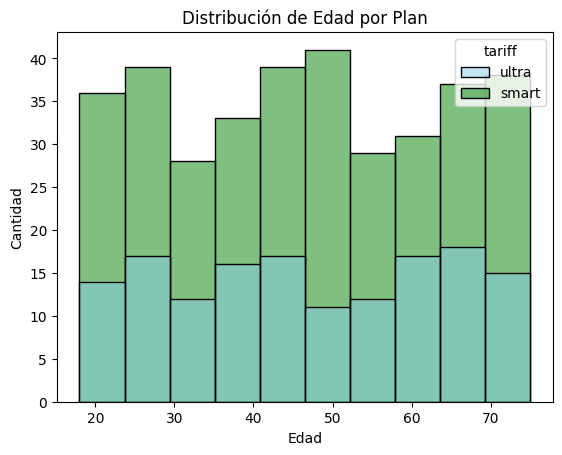

In [44]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='tariff', 
             palette=['skyblue','green'], bins=10)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.show()

💡Insights: 
- Distribución aproximadamente uniforme — todas las edades están bien representadas.
- El plan smart (verde) domina en todos los rangos de edad.
- No hay una edad específica que concentre más clientes ultra — ambos planes se distribuyen de forma similar a lo largo de todas las edades.
- No existe sesgo claro hacia ningún lado.


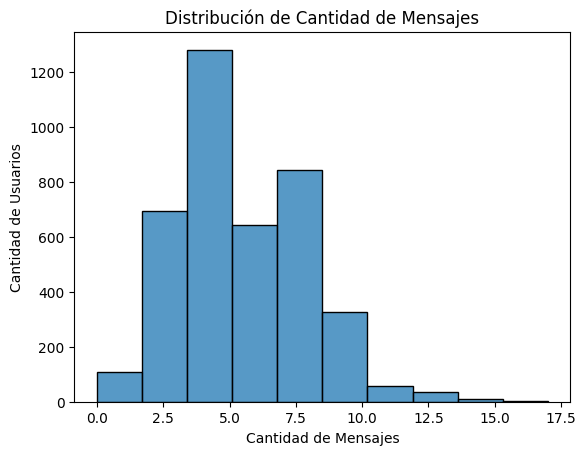

In [45]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=usage_agg, x='cant_mensajes', 
             palette=['skyblue','green'], bins=10)
plt.title('Distribución de Cantidad de Mensajes')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución sesgada a la derecha — la mayoría de usuarios envía entre 3 y 7 mensajes.
- El pico está en 5 mensajes — ese es el comportamiento típico del usuario.
- Pocos usuarios envían más de 10 mensajes — son casos atípicos.

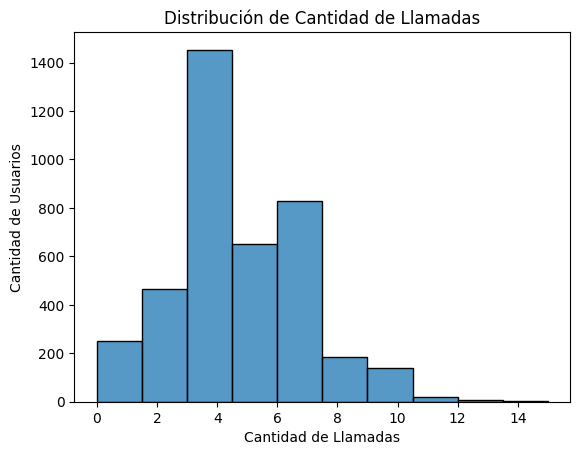

In [46]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=usage_agg, x='cant_llamadas',
             palette=['skyblue','green'], bins=10)
plt.title('Distribución de Cantidad de Llamadas')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución sesgada a la derecha — la mayoría de usuarios realiza entre 3 y 6 llamadas.
- El pico está en 4 llamadas — comportamiento típico del usuario de ConnectaTel.
- Muy pocos usuarios superan 10 llamadas — son casos atípicos a investigar.
- Patrón similar al de mensajes — uso moderado en general.

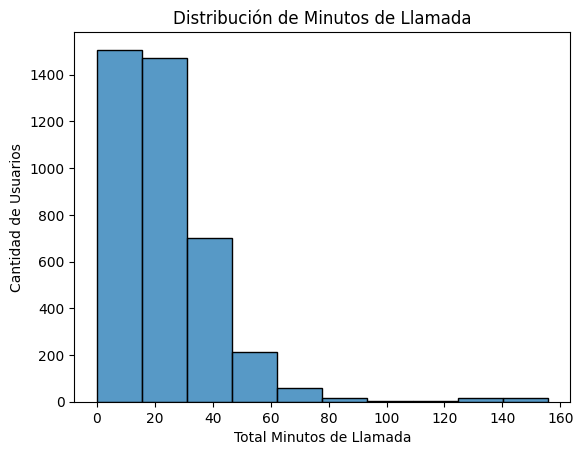

In [47]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=usage_agg, x='cant_minutos_llamada',
             palette=['skyblue','green'], bins=10)
plt.title('Distribución de Minutos de Llamada')
plt.xlabel('Total Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución fuertemente sesgada a la derecha.
- La mayoría de usuarios acumula entre 0 y 40 minutos de llamada en total.
- Muy pocos usuarios superan 80 minutos — son casos atípicos.
- El uso de minutos es bajo en general — oportunidad para ConnectaTel de promover planes con más minutos incluidos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

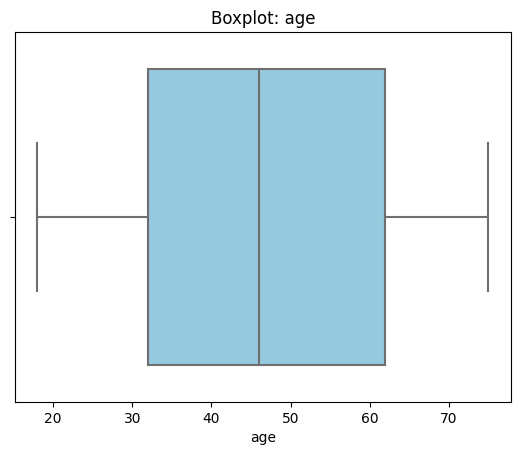

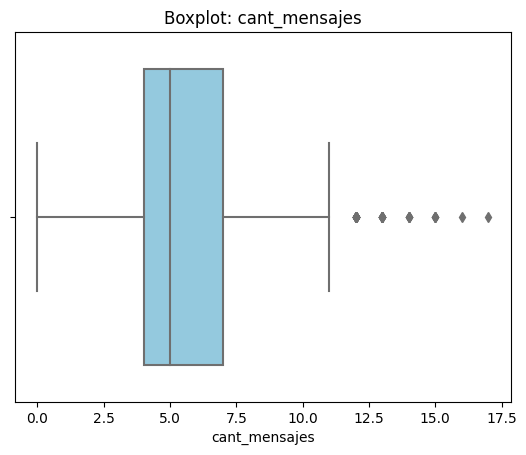

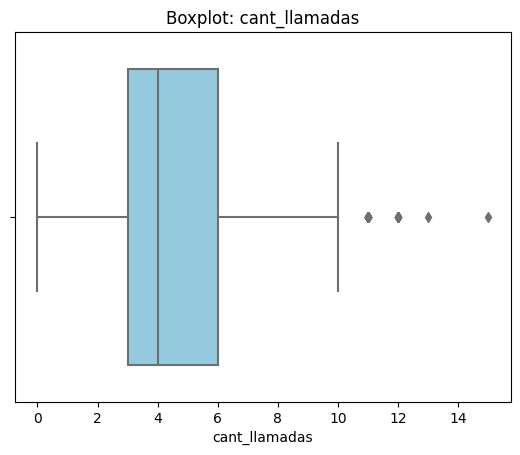

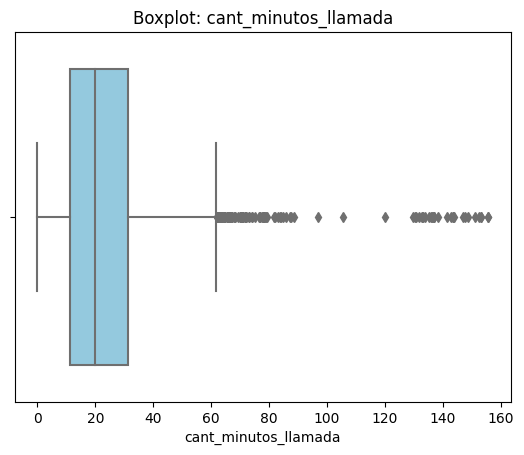

In [48]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    if col == 'age':
        sns.boxplot(x=user_profile[col], color='skyblue')
    else:
        sns.boxplot(x=usage_agg[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 

- Age: sin outliers — distribución simétrica, rango 18-75, sin valores extremos.
- cant_mensajes: outliers altos presentes — algunos usuarios envían más de 12 mensajes.
- cant_llamadas: outliers altos presentes — algunos usuarios realizan más de 10 llamadas.
- cant_minutos_llamada: muchos outliers altos — usuarios con más de 60 minutos, cola muy larga.

In [49]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1  = usage_agg[col].quantile(0.25)
    Q3  = usage_agg[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    print(f"{col} → Q3: {Q3:.2f}, IQR upper: {upper:.2f}, Max: {usage_agg[col].max():.2f}")



cant_mensajes → Q3: 7.00, IQR upper: 11.50, Max: 17.00
cant_llamadas → Q3: 6.00, IQR upper: 10.50, Max: 15.00
cant_minutos_llamada → Q3: 31.41, IQR upper: 61.86, Max: 155.69


In [50]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
usage_agg[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener outliers — max 17, límite IQR 11.5. 
  Diferencia moderada, representan usuarios activos reales.
- cant_llamadas: mantener outliers — max 15, límite IQR 10.5. 
  Diferencia moderada, comportamiento legítimo de usuarios frecuentes.
- cant_minutos_llamada: mantener outliers — max 155.69, límite IQR 61.86. 
  Cola larga significativa pero representa uso real de voz intensivo.
  No hay evidencia de errores de captura.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [53]:
# Crear columna grupo_uso
def classify_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

usage_agg['grupo_uso'] = usage_agg.apply(classify_uso, axis=1)

In [54]:
# verificar cambios
user_profile.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,grupo_edad
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,Adulto
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,Adulto
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,Adulto
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,Joven
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [51]:
# Crear columna grupo_edad
def classify_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(classify_edad, axis=1)


In [52]:
# verificar cambios
user_profile.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,grupo_edad
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,Adulto
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,Adulto
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,Adulto
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,Joven
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

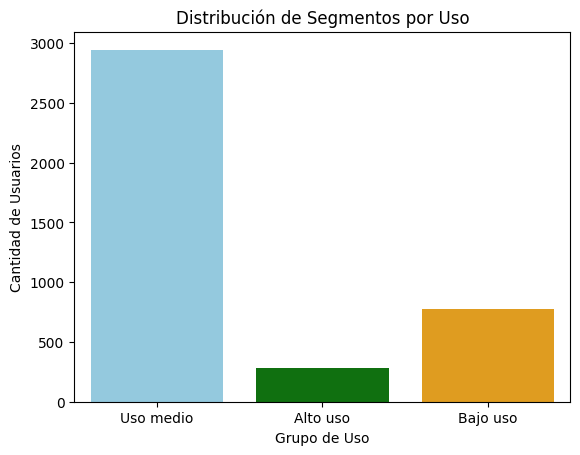

In [55]:

# Visualización de los segmentos por uso
sns.countplot(data=usage_agg, x='grupo_uso', palette=['skyblue','green','orange'])
plt.title('Distribución de Segmentos por Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

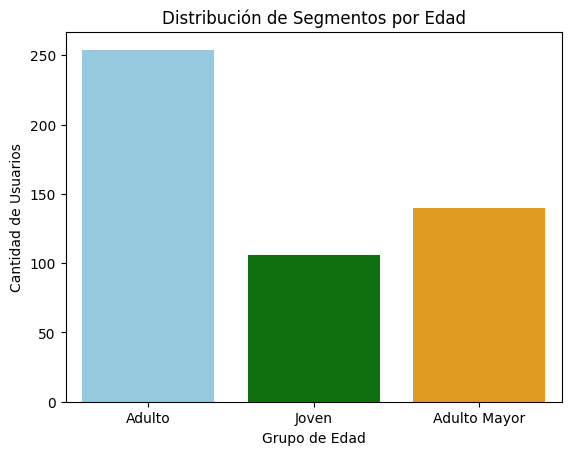

In [56]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue','green','orange'])
plt.title('Distribución de Segmentos por Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- `churn_date`: 462 nulos (92.4%) — clientes activos, se conservó como NaN.
- `date` en usage: 50 nulos (0.12%) — eliminados por ser irrelevantes para el análisis temporal.
- `duration` y `length`: nulos estructurales confirmados MAR — dependen del tipo de evento (call/text).
- Limitación crítica: user_id incompatibles entre users (1000-1499) y usage (10000-13999) — datasets analizados por separado

### Recomendaciones
- Diseñar campaña de migración de smart a ultra para usuarios de Alto uso.
- Crear plan intermedio para usuarios de Uso medio que superan ocasionalmente los límites del plan smart.
- Investigar la incompatibilidad de user_id entre sistemas para habilitar análisis integrado en el futuro.
- Enfocar estrategias de retención en el segmento Adulto Mayor — segundo grupo más grande con potencial de churn.

🔍 **Segmentos por Edad**
- Uso medio domina con ~3,000 usuarios — la mayoría hace entre 5-10 llamadas y mensajes.
- Bajo uso representa ~750 usuarios — potencial para campañas de activación.
- Alto uso solo ~300 usuarios — son los más valiosos para ConnectaTel.


📊 **Segmentos por Nivel de Uso**
- Uso medio domina con ~3,000 usuarios — la mayoría hace entre 5-10 llamadas y mensajes.
- Bajo uso representa ~750 usuarios — potencial para campañas de activación.
- Alto uso solo ~300 usuarios — son los más valiosos para ConnectaTel.

### Esto sugiere que...
El plan smart concentra el 70% de usuarios pero el segmento de Alto uso podría beneficiarse del plan ultra con más minutos y mensajes incluidos.


💡 **Recomendaciones**
- Diseñar campaña de migración de smart a ultra para usuarios de Alto uso.
- Crear plan intermedio para usuarios de Uso medio que superan ocasionalmente los límites del plan smart.
- Investigar la incompatibilidad de user_id entre sistemas para habilitar análisis integrado en el futuro.
- Enfocar estrategias de retención en el segmento Adulto Mayor — segundo grupo más grande con potencial de churn.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`